In [1]:
Threads.nthreads()

4

In [2]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2


  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Definició model

In [3]:
moving_source_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # X direction
        if x < xmin
            x += (xmax - xmin)
        elseif x > xmax
            x -= (xmax - xmin)
        end

        # Y direction
        if y < ymin
            y += (ymax - ymin)
        elseif y > ymax
            y -= (ymax - ymin)
        end

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            σ = sqrt(2*Ds*dt)
            x += σ * randn() 
            y += σ * randn()
            mm += S
        
        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end
        end

    end,

    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
        # elseif @mediumBorder(1,-1)
        #     mm = 0
        # elseif @mediumBorder(1,1)
        #     mm = 0
        # elseif @mediumBorder(2,1)
        #     mm = 0
        # elseif @mediumBorder(2,-1)
        #     mm = 0
        end
    end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    

# Carrega community

# Evoluciona i guarda

In [4]:
n_tries = 3
ns = [10]
steps = 10000

for n in ns
    for trial in 3:n_tries
        println("Running n=$n, trial=$trial")

        # Community
        com = Community(
            moving_source_model,
            N=21,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [200, 200]
        )

        m = 1/100
        g = 1/10000
        d = 1

        #Valors referencia
        Dc = 10
        delta = 0.01
        Ds = 10

        # #Changing omega
        com.Ds = Ds
        com.DMedium = Dc * n
        com.delta = delta * n


        com.Dr_run = 0.062
        com.v = 10.0
        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 8
        com.τm = 1.0
        com.α   = 6.0
        com.K = 2.0 
        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1
        
        com.methyl .= 0.0
        com.Yp .= com.K

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        com.x = 0.0
        com.y = 0.0
        com.theta = rand(Uniform(0,2π),com.N)
        src = 1
        com.isSource .= false
        com.isSource[src] = true
        com.active .= true 
        com.active[src] = false   
        com.S .= 0.0
        com.S[src] = 2.6

        loadToPlatform!(com, preallocateAgents=21)
        
        outfile = @sprintf("rm_omega_%s_%d.jld2", n, trial)


        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["N"] = com.N
            meta["NMedium"] = com.NMedium
            meta["steps"] = steps

            for step in 1:steps
                step!(com)

                if step %10000 == 0

                    stepname = @sprintf("step_%06d", step)
                    g = JLD2.Group(file, stepname)

                    # Agent-level arrays (length = N)
                    g["x"] = copy(com.x)
                    g["y"] = copy(com.y)
                    g["theta"] = copy(com.theta)
                    g["l"] = copy(com.l)
                    g["d"] = copy(com.d)
                    g["isSource"] = copy(com.isSource)

                    g["DMedium"] = copy(com.DMedium)
                    g["delta"] = copy(com.delta)
                    g["Ds"] = copy(com.Ds)
                end
            end
        end
    end
end


Running n=10, trial=3


# Plots

In [6]:
steps = 10000

10000

In [5]:
data = Dict{Int, Any}()
steps = 10000
jldopen("rm_lambda_05_1.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"]),
            "l" => copy(key["l"]),
            "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (200,200))

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                    )

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = g["l"]

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

In [6]:
save("source_track_DMed10.png", fig2)

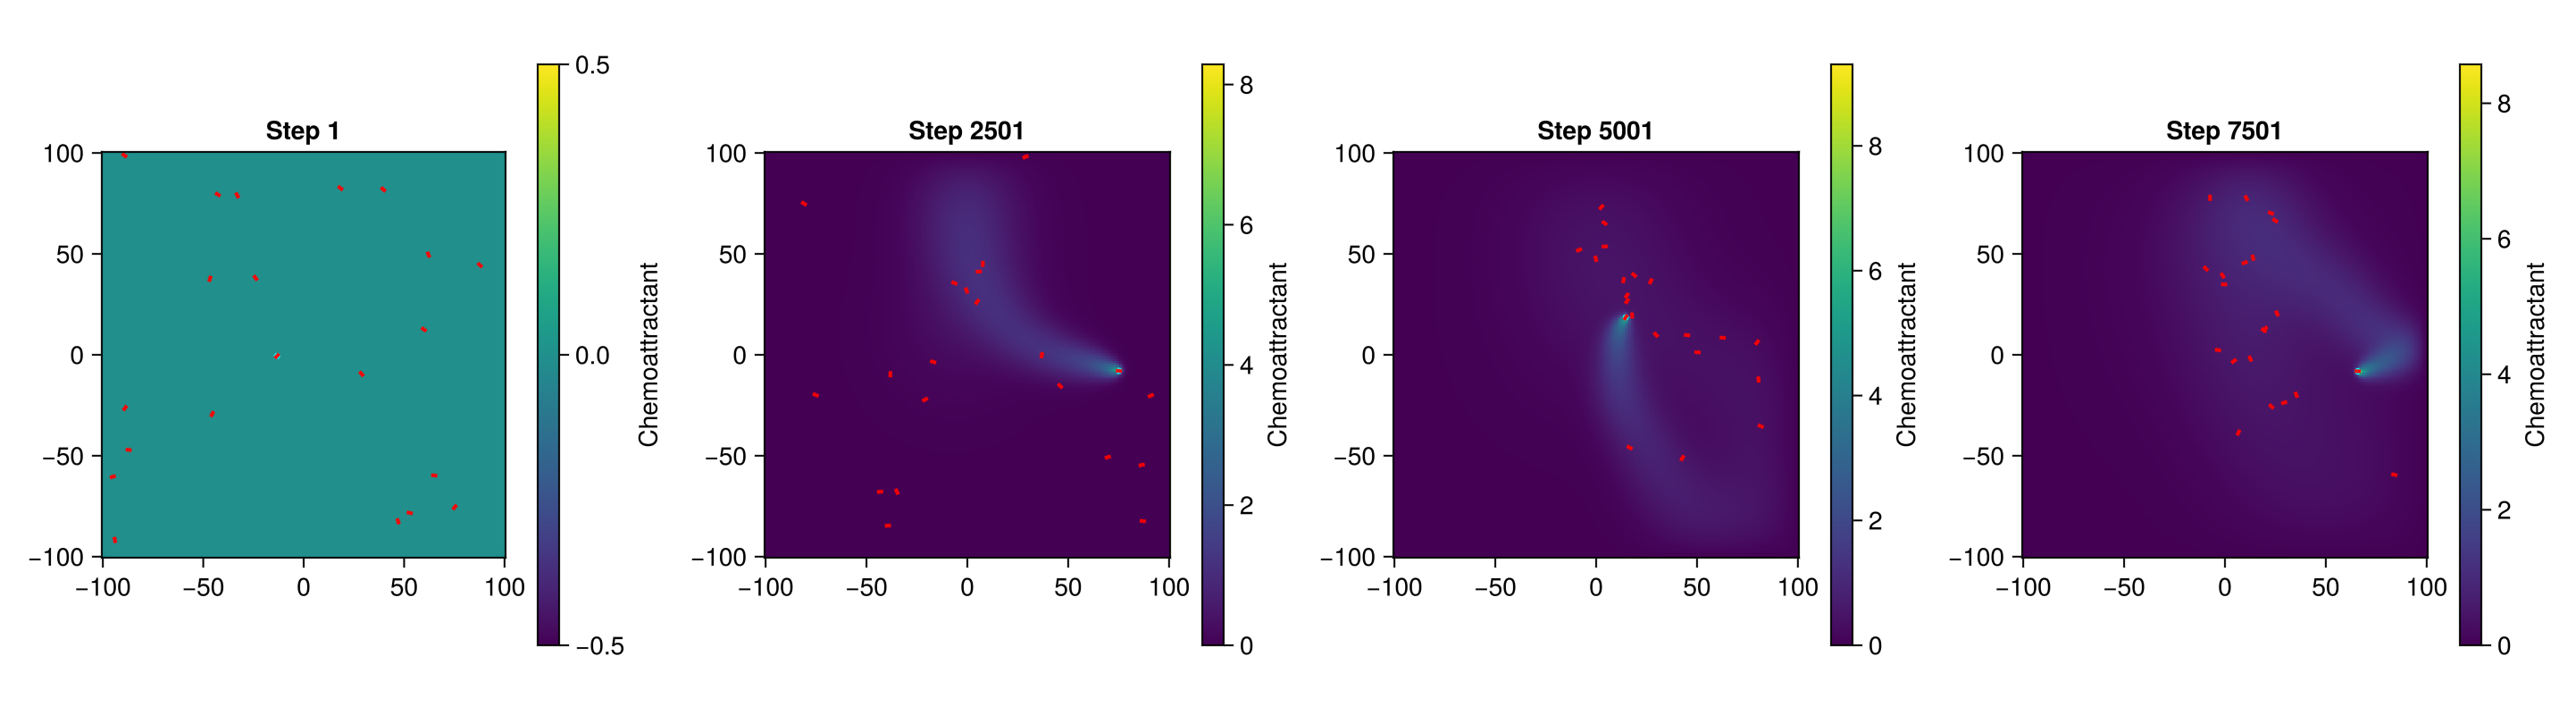

GLMakie.Screen(...)

In [5]:
fig4 = Figure(size=(1800,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

jldopen("source.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig4[1, 2*j-1], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (200,200))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = g["l"]
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [6]:
save("Plots/source_nous_parametres.png", fig4)

## Mean distance to source

In [6]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="time", ylabel="mean distance to source")

mean_dist = Float64[] 
std_dist = Float64[]

jldopen("rm_lambda_05_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]


        other_x = g["x"][2:com.N]

        other_y = g["y"][2:com.N]

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))
        push!(std_dist, std(dists))

    end

    time = (1:steps) * 0.01 
    slope = (steps * sum(time .* mean_dist) - sum(time) * sum(mean_dist)) / (steps * sum(time .^ 2) - sum(time)^2)
    intercept = mean(mean_dist) - slope * mean(time)

    std_dist_1 = std_dist ./ sqrt(com.N -1)

    lines!(ax1, (1:steps)*0.01, mean_dist)
    band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation") 

    text!(ax1, 0.05, 0.95,text =  "Slope = $(round(slope, digits=3)) μm/s", 
          align=(:left, :top), 
          fontsize=14, 
          color=:black)

    # sideinfo = Label(fig4[2, 1:2], "Model parameters = Box size: $(com.simBox), v: [$(com.v[1])μm/s], tm: [$(com.τm)s]", justification = :left, color = :grey)

    lines!(ax1, time, slope .* time .+ intercept, color=:red, linestyle=:dash, label="Linear fit")
end
display(fig)

GLMakie.Screen(...)

In [8]:
save("Plots/rm_lambda_2_1.png", fig)

In [5]:
l = sqrt(com.DMedium[1]/com.delta[1])
τs = l^2 / (2*com.Ds[1])
τv = l / com.v[1]
τc = l^2 / com.DMedium[1]

ratio_phi = com.τm[1] / τv
ratio_pi = com.τm[1] / τs
ratio_omega = com.τm[1] / τc

println("pi: ", ratio_pi, " phi: ", ratio_phi, " omega: ", ratio_omega)


pi: 1.0 phi: 1.0 omega: 1.0


In [21]:
lambdas = ["05", "1", "2", "5", "10"]
lambdas[1]

"05"

In [6]:
omegas = ["0.5", "1", "2", "5", "10"]
n_trials = 3

df_omega = DataFrame(
    omega = String[],
    trial = Int[],
    mean_r = Float64[],
    DMedium = Float64[],
    Ds = Float64[],
    delta = Float64[],
    l = Float64[],
    tm = Float64[],
    v = Float64[]
)

for λ in omegas
    for trial in 1:n_trials

        # # format lambda correctly for filename
        # λ_str = λ == 0.5 ? "05" : string(λ)
        # # λ_str = string(λ)
        # println(λ_str, typeof(λ_str))

        filename = @sprintf("rm_omega_%s_%d.jld2", λ, trial)

        jldopen(filename, "r") do file

            gdata = file[@sprintf("step_%06d", steps)]

            x = gdata["x"]
            y = gdata["y"]

            xs = x[1]
            ys = y[1]

            dist = sqrt.((x[2:end] .- xs).^2 .+ (y[2:end] .- ys).^2)
            mean_r = mean(dist)

            DMedium = gdata["DMedium"][1]
            delta_val = gdata["delta"][1]
            Ds = gdata["Ds"][1]
            tm_val = 1
            v_val = 10
            l = sqrt(DMedium / delta_val)


            push!(df_omega, (
                λ,
                trial,
                mean_r,
                DMedium,
                Ds,
                delta_val,
                l,
                tm_val,
                v_val
            ))
        end
    end
end

df_omega

Row,omega,trial,mean_r,DMedium,Ds,delta,l,tm,v
,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.5,1,92.3129,5.0,10.0,0.005,31.6228,1.0,10.0
2,0.5,2,64.564,5.0,10.0,0.005,31.6228,1.0,10.0
3,0.5,3,66.31,5.0,10.0,0.005,31.6228,1.0,10.0
4,1,1,54.3203,10.0,10.0,0.01,31.6228,1.0,10.0
5,1,2,109.392,10.0,10.0,0.01,31.6228,1.0,10.0
6,1,3,98.8094,10.0,10.0,0.01,31.6228,1.0,10.0
7,2,1,96.2725,20.0,10.0,0.02,31.6228,1.0,10.0
8,2,2,89.7664,20.0,10.0,0.02,31.6228,1.0,10.0
9,2,3,57.2978,20.0,10.0,0.02,31.6228,1.0,10.0


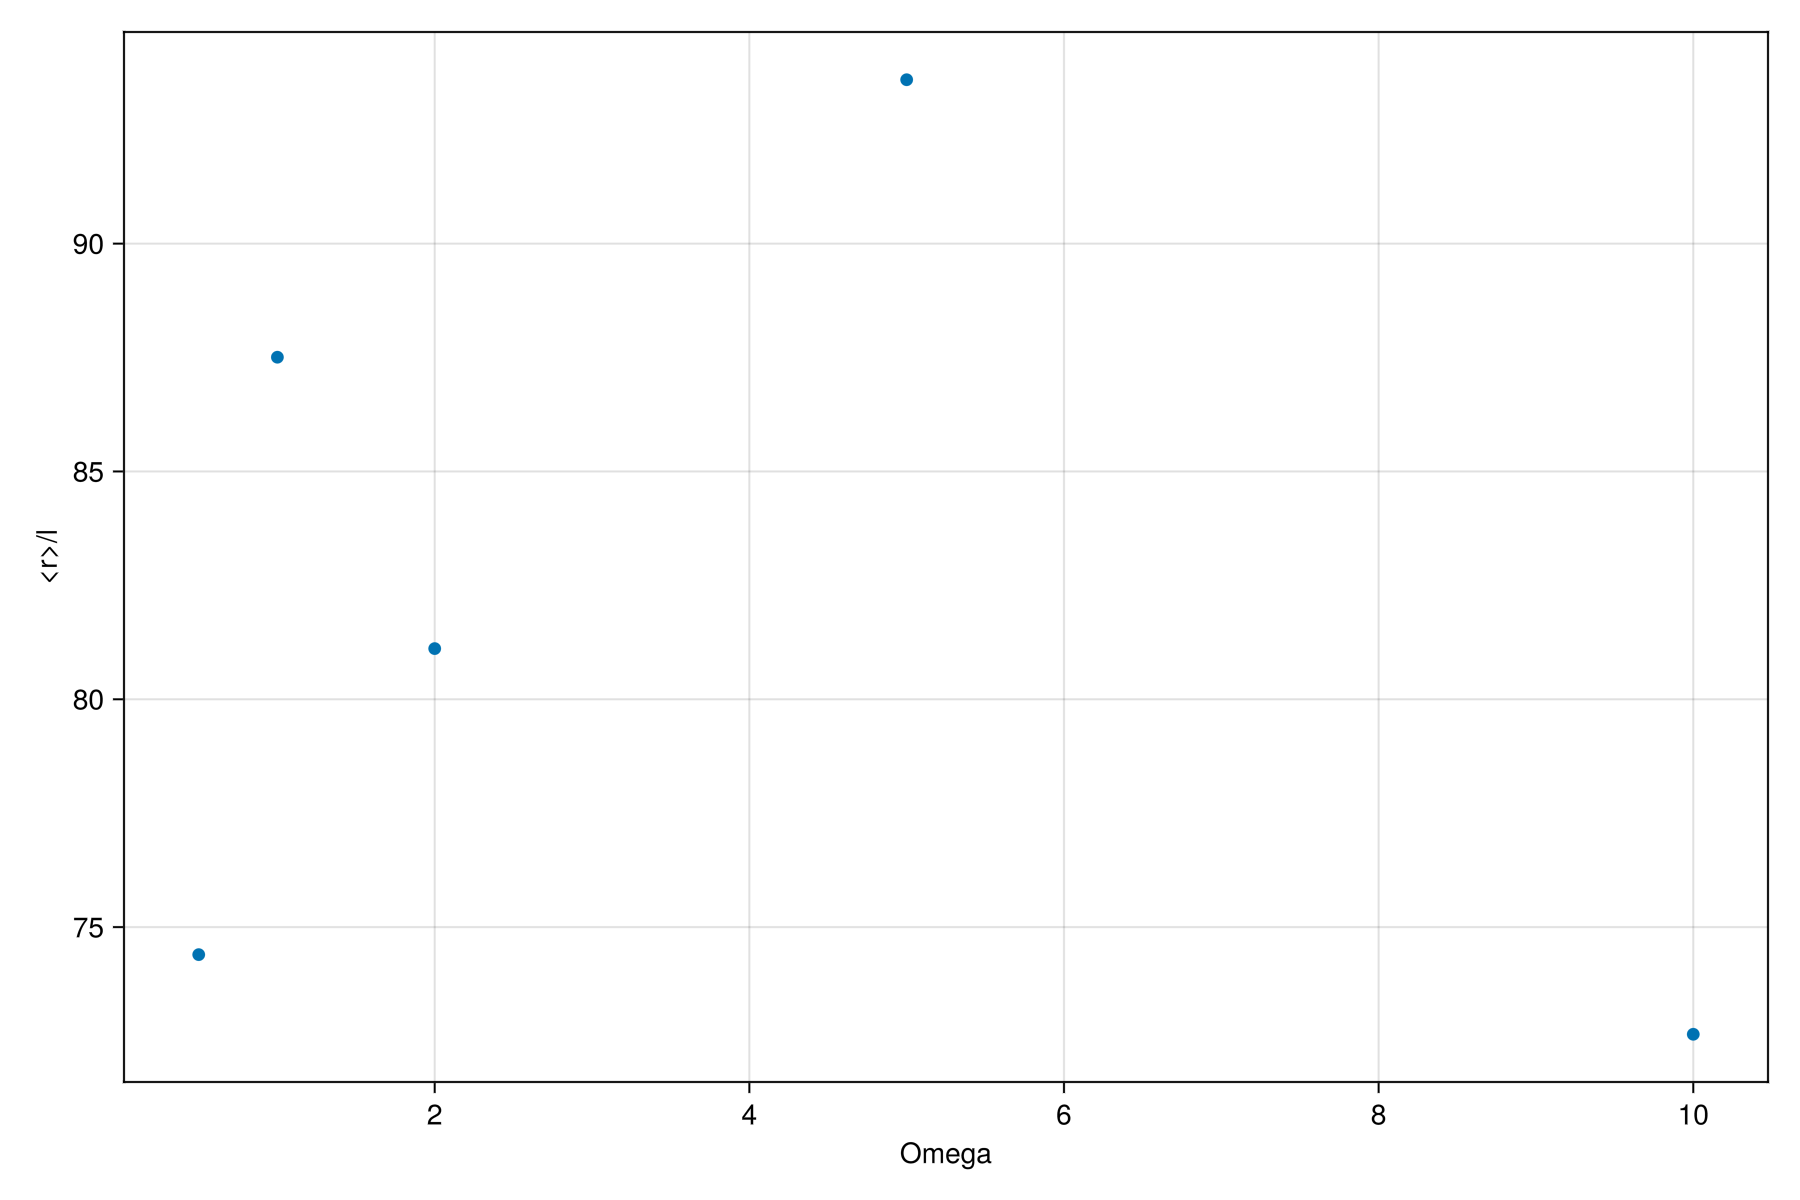

GLMakie.Screen(...)

In [9]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="Omega", ylabel="<r>/l")

r_l= Float64[] 
mean_sim = Float64[]

fr_l = Float64[]
omegas = [0.5, 1, 2, 5, 10]

group_size = 3
n_groups = length(df_omega.omega) ÷ group_size

for g in 1:n_groups
    
    group_mean = Float64[]

    # files 1:3, 4:6, 7:9
    for f in ((g-1)*group_size + 1):(g*group_size)
        mean = df_omega.mean_r[f]
        push!(group_mean, mean)
    end

    # mean of the 3 simulations in this group
    push!(r_l, mean(group_mean))

end


scatter!(ax1, omegas, r_l)

display(fig)

In [8]:
save("Omega_comparison_n.png", fig)

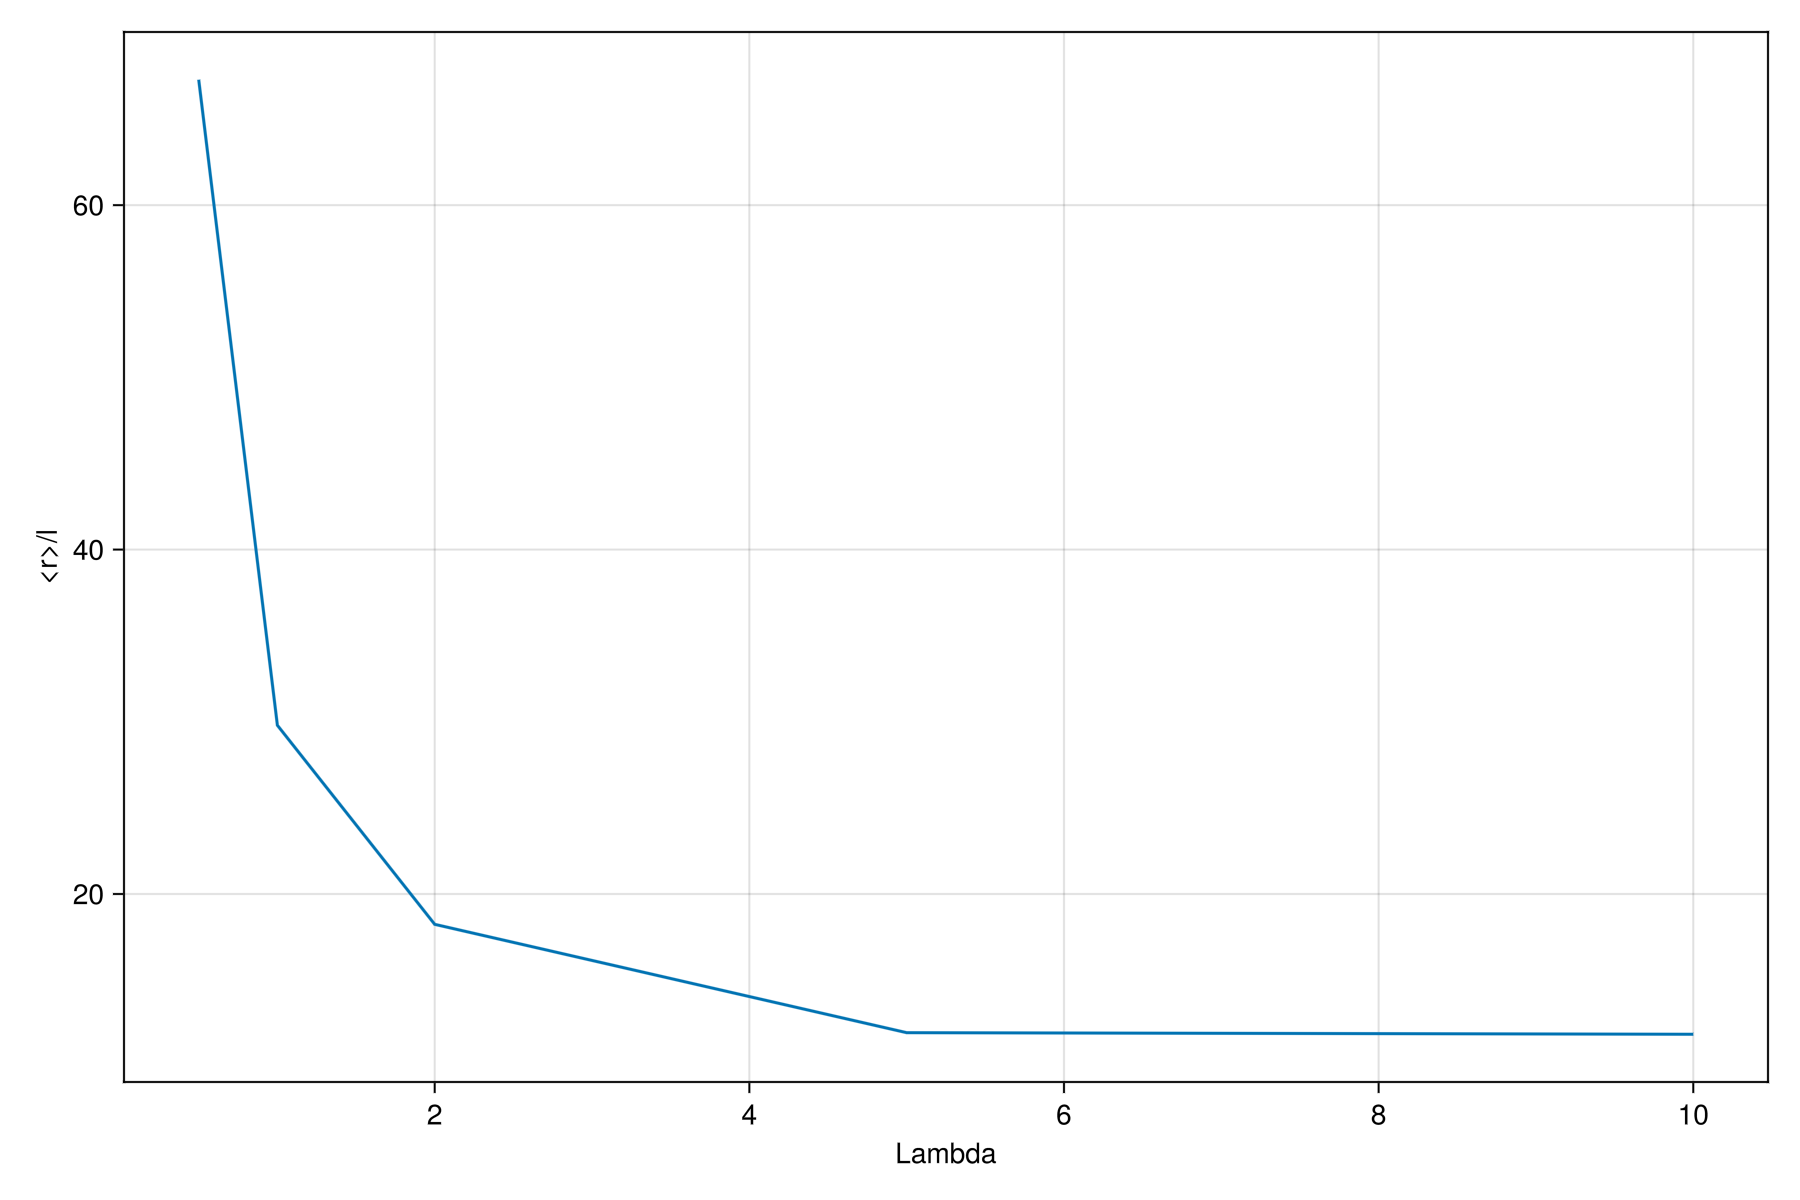

GLMakie.Screen(...)

In [7]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="Lambda", ylabel="<r>/l")

r_l= Float64[] 
mean_sim = Float64[]
lambdas = Float64[]

Dc = Vector{Float64}(undef, 1)
delta = Vector{Float64}(undef, 1)
tm = Vector{Float64}(undef, 1)
v = Vector{Float64}(undef, 1) 

filenames = Dict{Int, String}(
    1 =>"rm_lambda_05_1.jld2",
    2 =>"rm_lambda_05_2.jld2",
    3 =>"rm_lambda_05_3.jld2",
    4 =>"rm_lambda_1_1.jld2",
    5 =>"rm_lambda_1_2.jld2",
    6 =>"rm_lambda_1_3.jld2",
    7 =>"rm_lambda_2_1.jld2",
    8 =>"rm_lambda_2_2.jld2",
    9 =>"rm_lambda_2_3.jld2",
    10 =>"rm_lambda_5_1.jld2",
    11 =>"rm_lambda_5_2.jld2",
    12 =>"rm_lambda_5_3.jld2",
    13 =>"rm_lambda_10_1.jld2",
    14 =>"rm_lambda_10_2.jld2",
    15 =>"rm_lambda_10_3.jld2"
)

fr_l = Float64[]
lambdas = [0.5, 1, 2, 5, 10]

group_size = 3
n_groups = length(filenames) ÷ group_size

for g in 1:n_groups
    
    group_mean = Float64[]
    
    # files 1:3, 4:6, 7:9
    for f in ((g-1)*group_size + 1):(g*group_size)
        
        jldopen(filenames[f], "r") do file
            gdata = file[@sprintf("step_%06d", steps)]

            xs = gdata["x"][1]
            ys = gdata["y"][1]

            other_x = gdata["x"][2:com.N]
            other_y = gdata["y"][2:com.N]

            dist = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

            push!(group_mean, mean(dist))
        end
    end

    # mean of the 3 simulations in this group
    push!(r_l, mean(group_mean))

end


lines!(ax1, lambdas, r_l)

display(fig)

In [8]:
save("Lambdas_compare.png", fig)